In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.datasets import fetch_california_housing

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

In [2]:
RANDOM_STATE=42

In [4]:
df = fetch_california_housing(as_frame=True)

x = df.data
y = df.target

По кросс валидации оценим качество решающего дерева и качество кросс-валидации

Для подбора гиперпараметров модели лучше всего действовать так:
* разбиваем данные на train и test
* на train по кросс-валидации при помощи GridSearchCV ищем наилучшие гиперпараметры модели
* оцениваем качество модели с наилучшими гиперпараметрами на test

In [6]:
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

print(f'Decision tree: {cross_val_score(dt, x, y, cv=3, scoring='r2').mean()}')
print(f'Random Forest: {cross_val_score(rf, x, y, cv=3, scoring='r2').mean()}')

Decision tree: 0.3262517155148194
Random Forest: 0.657374339413971


In [7]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=RANDOM_STATE)

Гиперпараметры леса (random forest)

* n_estimators=100 - число деревьев в лесе
* oob_score=False - вычисляем ли out-of-bag ошибку
* n_jobs=None - на сколько процессов распараллеливаем вычисления
* гиперпараметры деревьев:
  + criterion='squared_error'
  + max_depth=None
  + min_samples_split=2
  + random_state=None


In [ ]:
params = {'n_estimators': np.arange(10,200,20),
          'max_depth':np.arange(2,20,3)}

gs = GridSearchCV(RandomForestRegressor(), params, cv=3, scoring='r2', verbose=2)

gs.fit(xtrain, ytrain)

In [ ]:
gs.best_score_, gs.best_estimator_

# 0.7931685623299155
# RandomForestRegressor(max_depth=17, n_estimators=190)

In [ ]:
params = {'max_features':[None, 'sqrt', 'log2']}

gs = GridSearchCV(RandomForestRegressor(n_estimators=190, max_depth=17), params, cv=3, scoring='r2', verbose=2)

gs.fit(xtrain, ytrain)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ..................................max_features=None; total time=  13.1s
[CV] END ..................................max_features=None; total time=  12.8s
[CV] END ..................................max_features=None; total time=   9.1s
[CV] END ..................................max_features=sqrt; total time=   3.5s
[CV] END ..................................max_features=sqrt; total time=   4.1s
[CV] END ..................................max_features=sqrt; total time=   4.0s
[CV] END ..................................max_features=log2; total time=   4.8s
[CV] END ..................................max_features=log2; total time=   4.0s
[CV] END ..................................max_features=log2; total time=   4.1s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...stimators=190)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': [None, 'sqrt', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [12]:
gs.best_score_, gs.best_estimator_

(np.float64(0.807304328453169),
 RandomForestRegressor(max_depth=17, max_features='log2', n_estimators=190))

In [13]:
model = RandomForestRegressor(n_estimators=190, max_depth=17, max_features='log2')
model.fit(xtrain, ytrain)
pred = model.predict(xtest)
r2_score(ytest, pred)

0.8145526017307214

Посмотрим, как зависит качество леса от количества деревьев

Text(0, 0.5, 'r2')

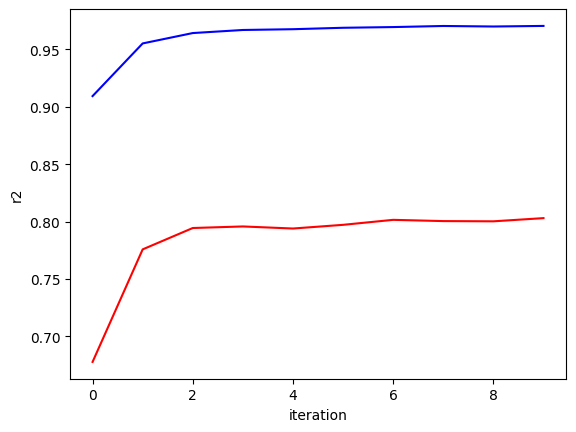

In [16]:
r2_train = []
r2_test = []

for i in range(2, 50, 5):
    model = RandomForestRegressor(n_estimators=i, n_jobs=-1)
    model.fit(xtrain, ytrain)

    pred_train = model.predict(xtrain)
    pred_test = model.predict(xtest)

    r2_train.append(r2_score(ytrain, pred_train))
    r2_test.append(r2_score(ytest, pred_test))

plt.plot(r2_train, c='b')
plt.plot(r2_test, c='r')
plt.xlabel('iteration')
plt.ylabel('r2')

Мы видим, что при увеличении числа деревьев, качество и на трейне, и на тесте только растет. Это свойство случайного леса. Можно не бояться переобучиться, беря большое количество деревьев. Однако, рано или поздно улучшение будет совсем незначительным, будет расти только время ожидания